# Custom Envelope Functions

The `AnalyticKernel` models starspot appearance and disappearance with a **trapezoidal squared envelope**: spots rise linearly with timescale `tau`, hold a constant flux deficit for duration `lspot`, then decay symmetrically.

The kernel is computed as:

$$K(\tau) = R_\Gamma(\tau) \cdot \sigma_k^2 \sum_n |c_n|^2 \cos(n\,\omega_0\,\tau)$$

where $R_\Gamma(\tau) = \langle \Gamma(t)\,\Gamma(t+\tau)\rangle$ is the **autocorrelation of the squared envelope** $\Gamma(t) = \alpha^2(t)/\alpha_{\rm max}^2$.

There are two ways to define a custom envelope:

| Approach | When to use |
|----------|-------------|
| **`params.register_envelope`** (`src_jax`) | Preferred. Register a new spec so that `resolve_hparam`, `GPSolver`, and `MCMCSampler` all understand it automatically. |
| **Subclass `AnalyticKernel`** (`src_numpy` or `src_jax`) | For one-off usage when you need to override `R_Gamma` and `compute_psd` without touching the registry. |

This notebook demonstrates both patterns with a **Gaussian envelope** and compares it to the default trapezoidal one.

## Deriving $R_\Gamma$ for a Gaussian envelope

For $\Gamma(t) = \exp(-t^2/2\sigma^2)$, the autocorrelation is the convolution of $\Gamma$ with itself:

$$R_\Gamma(\tau) = \int_{-\infty}^{\infty} \Gamma(t)\,\Gamma(t+\tau)\,dt$$

We work through this step by step in sympy.

In [1]:
from sympy import *

t, tau, sigma, omega = symbols('t tau sigma omega', real=True, positive=True)

# Define the envelope
Gamma = exp(-t**2 / (2 * sigma**2))
Gamma

exp(-t**2/(2*sigma**2))

In [2]:
# Write out the integrand Γ(t) · Γ(t + τ)
integrand = Gamma * Gamma.subs(t, t + tau)
integrand = powsimp(expand(integrand))
integrand

exp(-t**2/sigma**2 - t*tau/sigma**2 - tau**2/(2*sigma**2))

In [3]:
# Integrate the integrand over t from -∞ to ∞
R_Gamma = integrate(integrand, (t, -oo, oo)).simplify()
R_Gamma

sqrt(pi)*sigma*exp(-tau**2/(4*sigma**2))

In [4]:
# Take the Fourier transform of R_Gamma to get Γ²(ω):
Gamma2_omega = integrate(R_Gamma * exp(-I * omega * tau), (tau, -oo, oo)).simplify()
Gamma2_omega

2*pi*sigma**2*exp(-omega**2*sigma**2)

In [5]:
sqrt(Gamma2_omega)

sqrt(2)*sqrt(pi)*sigma*exp(-omega**2*sigma**2/2)

## Approach 1 — Subclassing `AnalyticKernel` (`src_numpy`)

For a Gaussian squared envelope $\Gamma(t) = \exp(-t^2/2\sigma^2)$, the autocorrelation derived above is:

$$R_\Gamma(\tau) = \sigma\sqrt{\pi}\,\exp\!\left(-\frac{\tau^2}{4\sigma^2}\right)$$

and its Fourier transform is:

$$\hat{\Gamma}(\omega) = \sigma\sqrt{2\pi}\,\exp\!\left(-\frac{\sigma^2\omega^2}{2}\right)$$

Override `__init__` to accept `sigma` instead of `tau`, provide a dummy `lspot=0` to satisfy the parent's validation, and override `R_Gamma` and `compute_psd`.

In [8]:
import sys
sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt

from src_numpy.analytic_kernel import AnalyticKernel

In [9]:
_GAUSSIAN_REQUIRED_KEYS = {"peq", "kappa", "inc", "sigma"}

class GaussianEnvelopeKernel(AnalyticKernel):
    """
    AnalyticKernel with a Gaussian squared-envelope autocorrelation.

    The squared envelope is Γ(t) = exp(-t²/(2σ²)), so its autocorrelation
    R_Γ(τ) = sqrt(π) · σ · exp(-τ²/(4σ²)).

    Custom hparam keys
    ------------------
    sigma   : float  — Gaussian envelope width [days]  (replaces tau)
    lspot   : not required  (no plateau in a Gaussian envelope)

    All other AnalyticKernel keys (peq, kappa, inc, sigma_k / nspot_rate+fspot+alpha_max)
    are required as usual.
    """

    def __init__(self, hparam, **kwargs):
        missing = _GAUSSIAN_REQUIRED_KEYS - set(hparam)
        if missing:
            raise ValueError(f"hparam missing required keys: {missing}")

        # Build a parent-compatible copy: map sigma -> tau, supply dummy lspot
        parent_hparam = dict(hparam)
        parent_hparam["tau"]   = hparam["sigma"]
        parent_hparam.setdefault("lspot", 0.0)   # unused; satisfies parent validation

        super().__init__(parent_hparam, **kwargs)
        self.sigma = hparam["sigma"]   # expose under the natural name

    def R_Gamma(self, lag):
        """Autocorrelation of a Gaussian squared envelope."""
        t = np.abs(np.asarray(lag, dtype=float))
        norm = np.sqrt(np.pi) * self.sigma
        return np.exp(-t**2 / (4 * self.sigma**2)) * norm

    def _gamma_hat(self, omega):
        """Fourier transform of the Gaussian squared envelope."""
        return np.sqrt(2 * np.pi) * self.sigma * np.exp(-self.sigma**2 * omega**2 / 2)

    def compute_psd(self, omega, lat_dist=None):
        """Analytic PSD using the Gaussian envelope Fourier transform."""
        omega = np.asarray(omega, dtype=float)
        if lat_dist is None:
            lat_dist = lambda phi: 1.0

        def _psd_at_lat(phi):
            cn_sq = self.cn_squared(phi)
            w0 = self.omega0(phi)
            contrib = cn_sq[0] * self._gamma_hat(omega)**2
            for n in range(1, len(cn_sq)):
                Gh_plus  = self._gamma_hat(omega - n * w0)
                Gh_minus = self._gamma_hat(omega + n * w0)
                contrib += cn_sq[n] * (Gh_plus**2 + Gh_minus**2)
            return contrib

        phi_min, phi_max = self.lat_range
        phi_grid = np.linspace(phi_min, phi_max, self.n_lat)
        user_weights = np.array([lat_dist(float(p)) for p in phi_grid])
        norm = np.trapezoid(user_weights, phi_grid)

        all_contribs = np.array([_psd_at_lat(float(phi)) for phi in phi_grid])
        psd = np.trapezoid(user_weights[:, None] * all_contribs, phi_grid, axis=0)
        return omega / (2 * np.pi), psd / norm * self.sigma_k**2

## Compare envelope shapes

First, look at the autocorrelation functions $R_\Gamma(\tau)$ for the two envelope models.

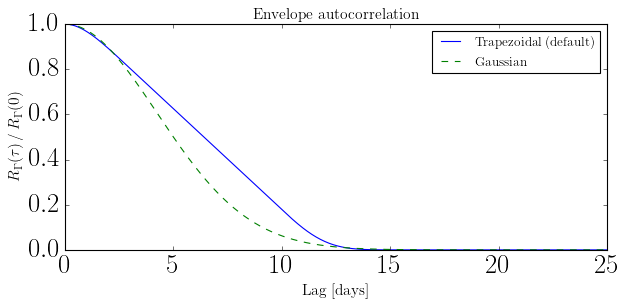

In [10]:
hparam_trap = dict(
    peq=5.0,
    kappa=0.2,
    inc=np.pi / 3,
    lspot=10.0,
    tau=3.0,
    sigma_k=0.01,
)

# Gaussian hparam: uses 'sigma' instead of 'tau', no 'lspot' required
hparam_gauss = dict(
    peq=5.0,
    kappa=0.2,
    inc=np.pi / 3,
    sigma=3.0,
    sigma_k=0.01,
)

ak_trap  = AnalyticKernel(hparam_trap, n_harmonics=3, n_lat=64)
ak_gauss = GaussianEnvelopeKernel(hparam_gauss, n_harmonics=3, n_lat=64)

tlags = np.linspace(0, 25, 500)

R_trap  = ak_trap.R_Gamma(tlags)
R_gauss = ak_gauss.R_Gamma(tlags)

plt.figure(figsize=(8, 4))
plt.plot(tlags, R_trap  / R_trap[0],  label="Trapezoidal (default)")
plt.plot(tlags, R_gauss / R_gauss[0], label="Gaussian", ls="--")
plt.axhline(0, color="gray", lw=0.8)
plt.xlabel("Lag [days]", fontsize=14)
plt.ylabel(r"$R_\Gamma(\tau)\,/\,R_\Gamma(0)$", fontsize=14)
plt.title("Envelope autocorrelation", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Compare GP kernels

Now evaluate the full GP kernel $K(\tau)$ for both envelope models.

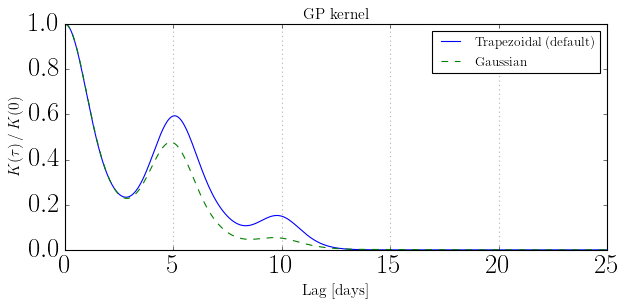

In [11]:
K_trap  = ak_trap(tlags)
K_gauss = ak_gauss(tlags)

plt.figure(figsize=(8, 4))
plt.plot(tlags, K_trap  / K_trap[0],  label="Trapezoidal (default)")
plt.plot(tlags, K_gauss / K_gauss[0], label="Gaussian", ls="--")
for ii in range(1, 6):
    plt.axvline(ii * hparam_trap["peq"], color="gray", ls=":", alpha=0.6)
plt.axhline(0, color="gray", lw=0.8)
plt.xlabel("Lag [days]", fontsize=14)
plt.ylabel(r"$K(\tau)\,/\,K(0)$", fontsize=14)
plt.title("GP kernel", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Compare power spectral densities

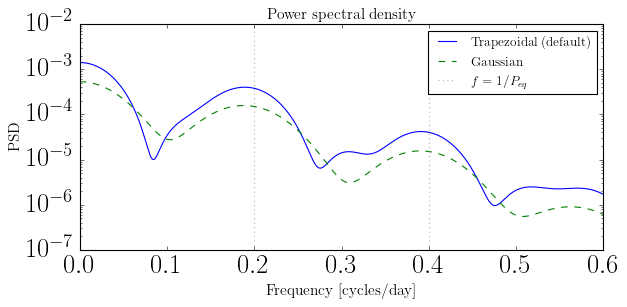

In [12]:
omega = np.linspace(0, 6 * np.pi / hparam_trap["peq"], 1000)

freq_trap,  psd_trap  = ak_trap.compute_psd(omega)
freq_gauss, psd_gauss = ak_gauss.compute_psd(omega)

plt.figure(figsize=(8, 4))
plt.semilogy(freq_trap,  psd_trap,  label="Trapezoidal (default)")
plt.semilogy(freq_gauss, psd_gauss, label="Gaussian", ls="--")
for ii in range(1, 4):
    plt.axvline(ii / hparam_trap["peq"], color="gray", ls=":", alpha=0.6,
                label=f"$f={ii}/P_{{eq}}$" if ii == 1 else None)
plt.xlabel("Frequency [cycles/day]", fontsize=14)
plt.ylabel("PSD", fontsize=14)
plt.title("Power spectral density", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Approach 2 — `register_envelope` (`src_jax`)

For `src_jax`, the preferred way to add a new envelope is through the
`params` registry. This makes the new envelope visible to `resolve_hparam`,
`GPSolver`, and `MCMCSampler` automatically — no subclassing required.

Steps:
1. Write a `resolve` function `(raw: dict) -> dict` that accepts the raw hparam
   dict and returns derived keys to inject (must include `'tau'` for scalar-tau
   compatibility with `GPSolver` and bandwidth estimation).
2. Call `register_envelope(EnvelopeSpec(...))` once at import time.
3. In `AnalyticKernel`, override `R_Gamma` to dispatch on the new key.

In [ ]:
import sys
sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from src_jax.params import EnvelopeSpec, register_envelope
from src_jax.analytic_kernel import AnalyticKernel as AnalyticKernelJAX

# ── 1. Register the envelope ─────────────────────────────────────────────

def _resolve_gaussian(raw: dict) -> dict:
    """Inject tau = sigma for scalar-tau compat; expose sigma_gauss."""
    return {"tau": raw["sigma_gauss"], "sigma_gauss": raw["sigma_gauss"]}

try:
    register_envelope(EnvelopeSpec(
        name="gaussian",
        signature_keys=frozenset({"sigma_gauss"}),
        resolve=_resolve_gaussian,
        description="Gaussian decay: sigma_gauss sets the 1/e width [days]",
    ))
except ValueError:
    pass  # already registered if cell is re-run

# ── 2. Subclass AnalyticKernel to override R_Gamma ───────────────────────

class GaussianEnvelopeKernelJAX(AnalyticKernelJAX):
    """src_jax AnalyticKernel with a Gaussian envelope registered via params."""

    def R_Gamma(self, lag):
        """R_Γ(τ) = sqrt(π) · sigma · exp(-τ² / (4·sigma²))"""
        sigma = self.hparam["sigma_gauss"]
        t = jnp.abs(jnp.asarray(lag, dtype=float).ravel())
        return jnp.sqrt(jnp.pi) * sigma * jnp.exp(-t**2 / (4 * sigma**2))

# ── 3. Use it — same hparam dict pattern as any other kernel ─────────────

hparam_gauss_jax = dict(
    peq=5.0, kappa=0.2, inc=np.pi/3,
    lspot=0.0,       # unused by Gaussian envelope; required by base keys
    sigma_gauss=3.0, # identifies the gaussian envelope
    sigma_k=0.01,
)

ak_gauss_jax = GaussianEnvelopeKernelJAX(hparam_gauss_jax, n_harmonics=3, n_lat=64)

tlags = np.linspace(0, 25, 500)
K_gauss_jax = ak_gauss_jax(tlags)

plt.figure(figsize=(8, 4))
plt.plot(tlags, K_gauss_jax / K_gauss_jax[0], label="Gaussian (src_jax, registered)")
plt.axhline(0, color="gray", lw=0.8)
plt.xlabel("Lag [days]", fontsize=14)
plt.ylabel(r"$K(\tau)\,/\,K(0)$", fontsize=14)
plt.title("Gaussian GP kernel (src_jax)", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# The registered envelope is also understood by resolve_hparam:
from src_jax.params import resolve_hparam
resolved = resolve_hparam(hparam_gauss_jax)
print(f"Resolved sigma_k: {resolved['sigma_k']:.4f}")
print(f"Resolved tau (scalar compat): {resolved['tau']:.4f}")